# Amaranthus Transpiration Experiment

Researchers: Sofia Cominelli and Andres Patrignani

In [1]:
# Import python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
from scipy import stats

# Set format of dates for all plots
#date_form = DateFormatter("%b-%d")
date_form = DateFormatter("%d")


In [2]:
# Experiment constants
empty_bucket_mass = 1355 # g
soil_volume = 26050 # cm^3  Using a truncated cone equation: (1/3) * np.pi * 45.5 * (12.75**2 + 12.75 * 14.25 + 14.25**2) 
bulk_density = 1.15 # g/cm^3 obtained from WP4C analisys
dry_soil_mass = soil_volume * bulk_density
effective_porosity = 0.535 # g/cm^3. From the soil water retention curve
water_density = 0.997 # g/cm^3
area_bucket = 637.94# cm^2



In [3]:
# Scales for each treament
well_watered_scales = ["T","Z","P","V","R","X"]
stressed_scales = ["Q","W","S","Y","O","U"]


In [4]:
# Soil water retention curve (matric version)
# Obtain parameters from curve fitting exercise or from figure of SWRC
def swrc(theta):
    theta_res = 0.095
    theta_sat = 0.535
    alpha = 0.539
    n = 1.356
    m = 1-1/n
    theta_relative = (theta - theta_res)/(theta_sat - theta_res)
    psi = (((((theta_relative**(1/-m)))-1)**(1/n))) * (-1/alpha)
    psi[psi< -100_000] = np.nan
    return psi * -1


In [5]:
# Approximate the VWC at the PWP for this soil
swrc(np.array([0.1355]))

array([1508.27572359])

In [6]:
# Load scales data
df = pd.read_csv('../data/amaranthus_20210419.dat', skiprows=[0,2,3], na_values='NAN')
df.head()

,TIMESTAMP,RECORD,Batt_volt_Min,PTemp_Avg,mass_Z_Avg,temp_Z_Avg,mass_Y_Avg,temp_Y_Avg,mass_X_Avg,temp_X_Avg,...,mass_Q_Avg,temp_Q_Avg,mass_P_Avg,temp_P_Avg,mass_O_Avg,temp_O_Avg,AirTC_Avg,RH,PAR_Den_Avg,PAR_Tot_Tot
0,2021-04-16 17:00:00,1777,11.56,28.92,37.87,21.90,37.61,23.23,37.47,22.13,...,37.70,22.31,37.61,21.91,37.07,21.18,21.66,45.63,524.200,28307.350000
1,2021-04-16 18:00:00,1778,11.54,28.56,37.87,21.14,37.61,22.43,37.47,21.16,...,37.71,21.87,37.61,21.57,37.07,20.86,21.06,48.79,497.300,26852.580000
2,2021-04-16 19:00:00,1779,11.58,28.22,37.87,20.97,37.61,22.43,37.47,21.11,...,NaN,NaN,37.62,20.96,37.07,20.30,21.46,42.43,471.300,25450.480000
3,2021-04-16 20:00:00,1780,11.53,28.19,37.87,20.72,37.61,22.49,37.47,21.28,...,37.71,20.46,37.63,20.32,37.08,19.58,21.68,39.16,459.100,24792.900000
4,2021-04-16 21:00:00,1781,11.54,26.85,37.88,18.99,37.62,20.86,37.47,19.87,...,37.71,18.76,37.64,18.43,37.07,17.84,17.67,48.96,0.101,5.477365


In [7]:
# Set negative values to NaN
idx_negative = df[df.columns[2:]]<0
df[idx_negative] = np.nan

# Replace missing values
df.interpolate(method='linear', inplace=True)


In [8]:
# Convert dates to datetime format
df.TIMESTAMP = pd.to_datetime(df.TIMESTAMP, format="%Y-%m-%d %H:%M:%S")


In [9]:
# Filter data for the experiment
experiment_start_date = pd.to_datetime('2021-05-05 00:00:00', format="%Y-%m-%d %H:%M:%S")
experiment_end_date = pd.to_datetime('2021-05-31 23:00:00',format="%Y-%m-%d %H:%M:%S")
idx = (df['TIMESTAMP'] >= experiment_start_date) & (df['TIMESTAMP'] <= experiment_end_date)
df = df[idx]
df.reset_index(drop=True, inplace=True)
df.insert(1,'HOUR',df['TIMESTAMP'].dt.hour)



In [10]:
df.to_csv('../data/amaranthus_transpiration_qaqc.csv', index=False)

In [11]:
# Compute Vapor pressure deficit
e_sat = 0.611 * np.exp((17.502*df['AirTC_Avg'])/(df['AirTC_Avg'] + 240.97)) # kPa
e_act = e_sat * 0.4 # kPa  Not using df['RH'] because sensors was close to the plants from 5/15 and RH was too high
df['VPD'] = e_sat - e_act #Vapor preasure difference kPa


In [12]:
# Read data from Kansas Mesonet
mhk = pd.read_csv('../data/ks_mesonet_manhattan.csv')
mhk.TIMESTAMP = pd.to_datetime(mhk.TIMESTAMP, format="%Y-%m-%d %H:%M:%S")
idx = (mhk['TIMESTAMP'] >= experiment_start_date) & (mhk['TIMESTAMP'] <= experiment_end_date)
mhk = mhk[idx]
mhk.reset_index(drop=True, inplace=True)
mhk.head()

,TIMESTAMP,STATION,BATT_DL,BATT_HTR,PRESSUREAVG,SLPAVG,TEMP2MAVG,TEMP10MAVG,RELHUM2MAVG,RELHUM10MAVG,...,SOILPA20CM,SOILPA50CM,SOILVR5CM,SOILVR10CM,SOILVR20CM,SOILVR50CM,VWC5CM,VWC10CM,VWC20CM,VWC50CM
0,2021-05-05 00:00:00,Manhattan,12.74,3.20,98.01,101.95,6.92,8.33,68.87,63.51,...,1.8255,2.1294,1.2224,1.3091,1.4027,2.0035,0.22985,0.32198,0.38879,0.51243
1,2021-05-05 01:00:00,Manhattan,12.71,3.15,98.03,101.98,5.50,7.11,75.95,69.64,...,1.8254,2.1294,1.2199,1.3063,1.4009,2.0036,0.22949,0.32146,0.38873,0.51243
2,2021-05-05 02:00:00,Manhattan,12.68,3.11,98.02,101.98,4.90,6.11,78.77,73.83,...,1.8243,2.1295,1.2174,1.3036,1.3997,2.0034,0.22933,0.32095,0.38821,0.51248
3,2021-05-05 03:00:00,Manhattan,12.65,3.07,98.03,102.01,3.97,5.39,82.37,77.16,...,1.8241,2.1297,1.2152,1.3008,1.3976,2.0038,0.22881,0.32048,0.38810,0.51255
4,2021-05-05 04:00:00,Manhattan,12.61,3.03,98.04,102.04,3.71,4.80,82.41,78.64,...,1.8230,2.1302,1.2132,1.2983,1.3957,2.0039,0.22793,0.31999,0.38762,0.51274


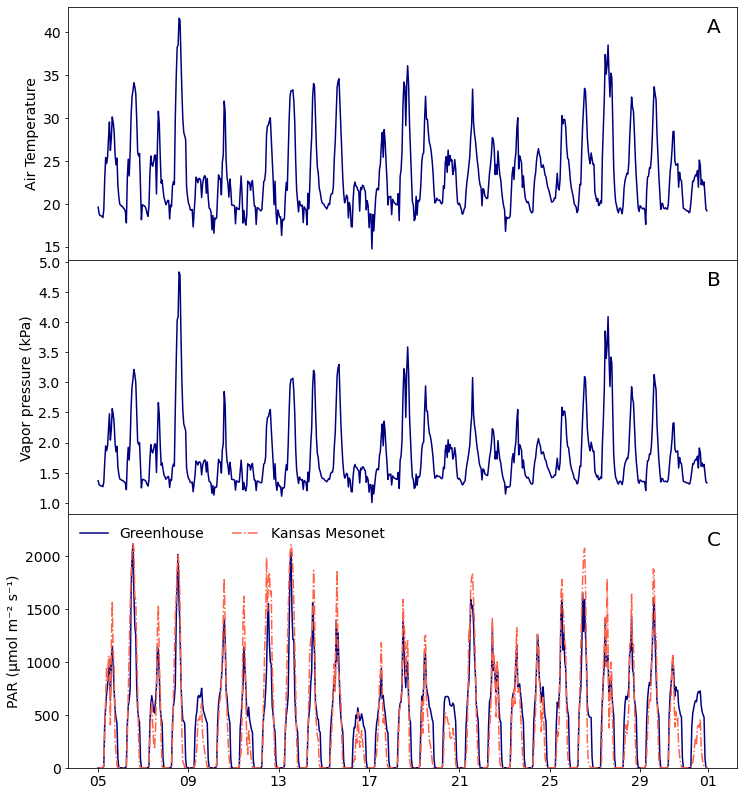

In [13]:
# Plot atmospheric conditions

fontsize = 14
plt.figure(figsize=(12,14))

plt.subplot(3,1,1)
plt.plot(df['TIMESTAMP'], df['AirTC_Avg'], color='navy')
plt.ylabel('Air Temperature', size=fontsize)
plt.text(df['TIMESTAMP'].iloc[-1], 40, 'A', size=20)
plt.xticks([])
plt.yticks(size=fontsize)

plt.subplot(3,1,2)
plt.plot(df['TIMESTAMP'], df['VPD'], color='navy')
plt.ylabel('Vapor pressure (kPa)', size=fontsize)
plt.text(df['TIMESTAMP'].iloc[-1], 4.6, 'B', size=20)
plt.xticks([])
plt.yticks(size=fontsize)

plt.subplot(3,1,3)
plt.plot(df['TIMESTAMP'], df['PAR_Den_Avg'], color='navy', label='Greenhouse')
plt.plot(mhk['TIMESTAMP'], mhk['SRAVG']*4.6*0.48, color='tomato', linestyle='-.', label='Kansas Mesonet')#f3.title.text = "PAR"
plt.ylabel('PAR (μmol m⁻² s⁻¹)', size=fontsize)
plt.ylim(0, 2400)

plt.xticks(size=fontsize)
plt.yticks(size=fontsize)
plt.legend(loc='upper left', fontsize=fontsize, frameon=False, ncol=2)
plt.gca().xaxis.set_major_formatter(date_form)


plt.subplots_adjust(hspace=0)
plt.savefig('../figures/environmental_conditions.jpg', dpi=300,  transparent=False)
plt.show()



Paper with some values of irradiance and PFFD to have as a reference.

Ritchie, R.J., 2010. Modelling photosynthetic photon flux density and maximum potential gross photosynthesis. Photosynthetica, 48(4), pp.596-609.

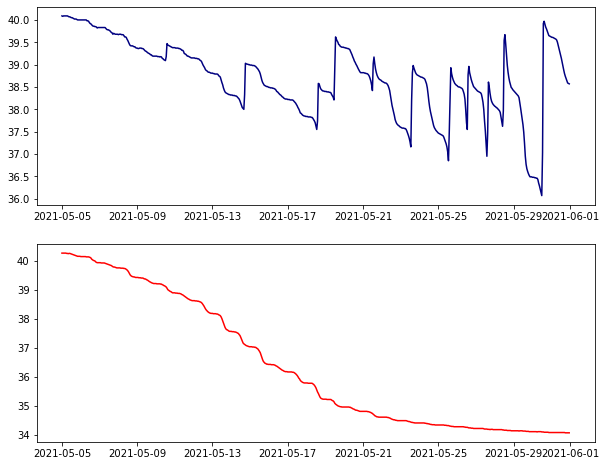

In [14]:
# Plot specific stressed and well-watered plants
plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
plt.plot(df['TIMESTAMP'], df['mass_T_Avg'], color='navy')

plt.subplot(2,1,2)
plt.plot(df['TIMESTAMP'], df['mass_U_Avg'], color='red')

plt.show()


In [15]:
# Compute transpiration rate for a specific plant

# Create function
def transpiration(scale,df):
    mass_change = df[scale].diff()
    idx_negative_change = mass_change > 0 # Change this to < 0 to visualize the irrigation events (irrigation events are discounted in the computation of transpiration)
    mass_change[idx_negative_change] = np.nan # To remove negative values
    mass_change.interpolate(method='linear',inplace=True) # Interpolate values set to NaN in previous step
    print(np.round(np.sum(np.abs(mass_change)),1))
    return np.abs(mass_change)



In [16]:
# Transpiration of individual well-water plants
Tr = pd.DataFrame()
Tr['TIMESTAMP'] = df['TIMESTAMP']
Tr['DATE'] = df['TIMESTAMP'].dt.date
Tr['T'] = transpiration('mass_T_Avg', df)
Tr['Z'] = transpiration('mass_Z_Avg', df)
Tr['P'] = transpiration('mass_P_Avg', df)
Tr['V'] = transpiration('mass_V_Avg', df)
Tr['R'] = transpiration('mass_R_Avg', df)
Tr['X'] = transpiration('mass_X_Avg', df)

# Transpiration of individual stressed plants
Tr['Q'] = transpiration('mass_Q_Avg', df)
Tr['W'] = transpiration('mass_W_Avg', df)
Tr['S'] = transpiration('mass_S_Avg', df)
Tr['Y'] = transpiration('mass_Y_Avg', df)
Tr['O'] = transpiration('mass_O_Avg', df)
Tr['U'] = transpiration('mass_U_Avg', df)


21.8
24.0
21.0
19.7
16.2
19.7
6.3
6.2
7.0
6.7
6.5
6.3


In [17]:
# Mean water use by well watered plants
Tr_well = Tr[well_watered_scales] * 1000
Tr_avg_well = Tr_well.mean(axis=1, skipna=True) # *1000/water_density/area_bucket*10 #convert from g to mm, 0.997 water density, 637.94 (np.pi*14.25**2) is the surface of the bucket, and 10 is to convert cm to mm
Tr_avg_well.interpolate(method='linear',inplace=True)
Tr_avg_well.interpolate(method='bfill',inplace=True) # Fill the first value

Tr_std_well = Tr_well.cumsum().std(axis=1, skipna=True) # *1000/water_density/area_bucket*10
Tr_std_well.interpolate(method='linear',inplace=True)
Tr_std_well.interpolate(method='bfill',inplace=True) # Fill the first value
Tr_ste_well = Tr_std_well/np.sqrt(6)



In [18]:
print(np.mean( Tr_well.sum(skipna=True)), 'grams')
print(np.mean( Tr_well.sum(skipna=True) * water_density/area_bucket*10), 'mm')
print(np.std( Tr_well.sum(skipna=True) * water_density/area_bucket*10), 'mm')


20399.58333333334 grams
318.81343987417836 mm
36.74671527607968 mm


In [19]:
# Typical water use by stressed plants
Tr_stress = Tr[stressed_scales] * 1000
Tr_avg_stress = Tr_stress.mean(axis=1, skipna=True) # *1000/water_density/area_bucket*10
Tr_avg_stress.interpolate(method='linear',inplace=True)
Tr_avg_stress.interpolate(method='bfill',inplace=True) # Fill the first value

Tr_std_stress = Tr_stress.cumsum().std(axis=1, skipna=True) #* 1000/water_density/area_bucket*10 #convert from g to mm, 0.997 water density, 637.94 (np.pi*14.25**2) is the surface of the bucket, and 10 is to convert cm to mm
Tr_std_stress.interpolate(method='linear',inplace=True)
Tr_std_stress.interpolate(method='bfill',inplace=True) # Fill the first value
Tr_ste_stress = Tr_std_stress/np.sqrt(6)

In [20]:
print(np.mean( Tr_stress.sum(skipna=True)), 'grams')
print(np.mean( Tr_stress.sum(skipna=True) * water_density/area_bucket*10), 'mm')
print(np.std( Tr_stress.sum(skipna=True) * water_density/area_bucket*10),  'mm')

6505.41666666666 grams
101.66944252855534 mm
4.738534384058122 mm


In [21]:
# Daily trasnpiration totals for each of the well-watered plants
Tr.groupby('DATE').sum()[well_watered_scales].mean(axis=1)*1000

DATE
2021-05-05     101.666667
2021-05-06     180.000000
2021-05-07     148.333333
2021-05-08     263.333333
2021-05-09     168.333333
2021-05-10     246.666667
2021-05-11     211.666667
2021-05-12     335.000000
2021-05-13     506.666667
2021-05-14     407.222222
2021-05-15     574.444444
2021-05-16     307.500000
2021-05-17     438.333333
2021-05-18     775.833333
2021-05-19     598.333333
2021-05-20     637.916667
2021-05-21    1222.500000
2021-05-22    1015.000000
2021-05-23     867.500000
2021-05-24    1183.333333
2021-05-25    1268.333333
2021-05-26    1743.333333
2021-05-27    1968.333333
2021-05-28    1749.166667
2021-05-29    1673.333333
2021-05-30     892.500000
2021-05-31     915.000000
dtype: float64

In [22]:
# Daily total trasnpiration of the stressed plants
Tr.groupby('DATE').sum()[stressed_scales].mean(axis=1)*1000

DATE
2021-05-05    123.333333
2021-05-06    185.833333
2021-05-07    169.166667
2021-05-08    310.833333
2021-05-09    186.111111
2021-05-10    281.388889
2021-05-11    258.333333
2021-05-12    389.166667
2021-05-13    544.166667
2021-05-14    430.833333
2021-05-15    508.333333
2021-05-16    225.000000
2021-05-17    340.833333
2021-05-18    535.000000
2021-05-19    306.666667
2021-05-20    210.833333
2021-05-21    375.833333
2021-05-22    208.333333
2021-05-23    166.666667
2021-05-24    140.000000
2021-05-25    138.333333
2021-05-26    124.166667
2021-05-27    100.000000
2021-05-28     80.416667
2021-05-29     76.666667
2021-05-30     56.666667
2021-05-31     32.500000
dtype: float64

### Run test for cumulative transpiration

In [23]:
# t-test to determine whether the total trasnpiration across the entire experiment was different
# for the well-watered and stressed treatments.
# Because of the large differences we expect to see a low p-value
stats.ttest_ind(Tr_well.sum().values, Tr_stress.sum().values)

Ttest_indResult(statistic=13.104884050256727, pvalue=1.2707940554798702e-07)

p-value<0.01. We reject the null hypothesis that the two populations have the same mean cumulative transpiration

In [24]:
print(Tr_well.sum().values)
print(Tr_stress.sum().values)

[21810.  23950.  20980.  19705.  16242.5 19710. ]
[6285.  6185.  7045.  6725.  6532.5 6260. ]


In [25]:
stats.levene(Tr_well.sum().values, Tr_stress.sum().values)

LeveneResult(statistic=5.836038254594814, pvalue=0.0363221365826558)

In [26]:
# Compute VWC for stressed plants

VWC = pd.DataFrame()
VWC['TIMESTAMP'] = df['TIMESTAMP']
VWC['DATE'] = df['TIMESTAMP'].dt.date
VWC['Q'] = (df['mass_Q_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC['W'] = (df['mass_W_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC['S'] = (df['mass_S_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC['Y'] = (df['mass_Y_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC['O'] = (df['mass_O_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC['U'] = (df['mass_U_Avg']*1000 - empty_bucket_mass - dry_soil_mass) / soil_volume
VWC.reset_index(inplace=True, drop=True)

VWC_daily = VWC.groupby('DATE', as_index=False).median()



In [27]:
# Compute Matric Potential for stressed plants
matric = pd.DataFrame()
matric['TIMESTAMP'] = df['TIMESTAMP']
matric['DATE'] = df['TIMESTAMP'].dt.date
matric['Q'] = swrc(VWC['Q'])
matric['W'] = swrc(VWC['W'])
matric['S'] = swrc(VWC['S'])
matric['Y'] = swrc(VWC['Y'])
matric['O'] = swrc(VWC['O'])
matric['U'] = swrc(VWC['U'])
matric.reset_index(inplace=True, drop=True)

#idx = matric[stressed_scales] > 10_000
#matric.loc[idx,[stressed_scales]] = np.nan


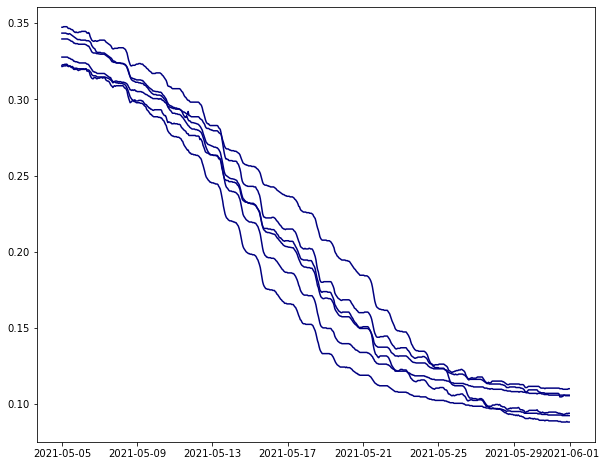

In [28]:
# Plot specific stressed and well-watered plants
plt.figure(figsize=(10,8))

plt.plot(df['TIMESTAMP'], VWC['Q'], color='navy')
plt.plot(df['TIMESTAMP'], VWC['W'], color='navy')
plt.plot(df['TIMESTAMP'], VWC['S'], color='navy')
plt.plot(df['TIMESTAMP'], VWC['Y'], color='navy')
plt.plot(df['TIMESTAMP'], VWC['O'], color='navy')
plt.plot(df['TIMESTAMP'], VWC['U'], color='navy')

plt.show()

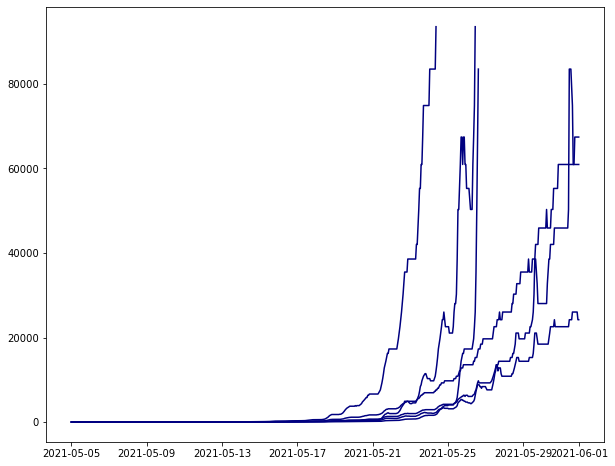

In [29]:
# Plot specific stressed and well-watered plants
plt.figure(figsize=(10,8))

plt.plot(df['TIMESTAMP'], matric['Q'], color='navy')
plt.plot(df['TIMESTAMP'], matric['W'], color='navy')
plt.plot(df['TIMESTAMP'], matric['S'], color='navy')
plt.plot(df['TIMESTAMP'], matric['Y'], color='navy')
plt.plot(df['TIMESTAMP'], matric['O'], color='navy')
plt.plot(df['TIMESTAMP'], matric['U'], color='navy')

plt.show()

In [30]:
# Find point at which the cumulative transpiration of the well-watered plants was above the stress plants.
# The value of 325 represents the point of divergence in Figure 3B. 
# The other values before 325 represent temporary values above during the first few days of the experiment.
idx_stress = np.where(Tr_avg_well.cumsum()>Tr_avg_stress.cumsum())
idx_stress


(array([  0,   1,   2,   3,   4,   5,   6,   7,   9,  10, 325, 326, 327,
        328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340,
        341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353,
        354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366,
        367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379,
        380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392,
        393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405,
        406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418,
        419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431,
        432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444,
        445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457,
        458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470,
        471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483,
        484, 485, 486, 487, 488, 489, 490, 491, 492

In [31]:
idx_stress = np.where(Tr_avg_well.cumsum()>Tr_avg_stress.cumsum())
idx_stress = 325 # Get this from the output of the previous cell

# Get VPD and timestamp of the day of the onset of the soil water stress (dashed line in Figure 3)
print(df.loc[idx_stress,'TIMESTAMP'])
print(df.loc[idx_stress,'VPD'])


2021-05-18 13:00:00
3.2241509535691972


In [32]:
# Find VWC and matric potential at point of stress
VWC_stress = VWC.loc[idx_stress,stressed_scales]
print(VWC_stress.median())
print(swrc(VWC_stress).median())


0.1818618042226489
176.9110165619349


In [33]:
# Find VWC and matric potential at point 1
VWC_stress = VWC.loc[idx_stress-21,stressed_scales]
print(VWC_stress.median())
print(swrc(VWC_stress).median())

0.19452975047984658
120.51785338547276


In [34]:
# Find VWC and matric potential at 48 hours after the point of stress
VWC_stress = VWC.loc[idx_stress+48,stressed_scales]
print(VWC_stress.median())
print(swrc(VWC_stress).median())

0.1535508637236086
535.8178606923125


In [35]:
 df['TIMESTAMP'].iloc[idx_stress+48] - pd.to_datetime('2021-05-17 16:00:00')

Timedelta('2 days 21:00:00')

In [129]:
print(VWC_stress.iloc[-1])
swrc(np.array([0.13656]))

0.1365642994241844


array([1402.68026998])

In [131]:
VWC_stress = VWC[stressed_scales].iloc[-1]
print(VWC_stress.median())
print(swrc(VWC_stress).median())

0.09971209213051838
60934.81010129806


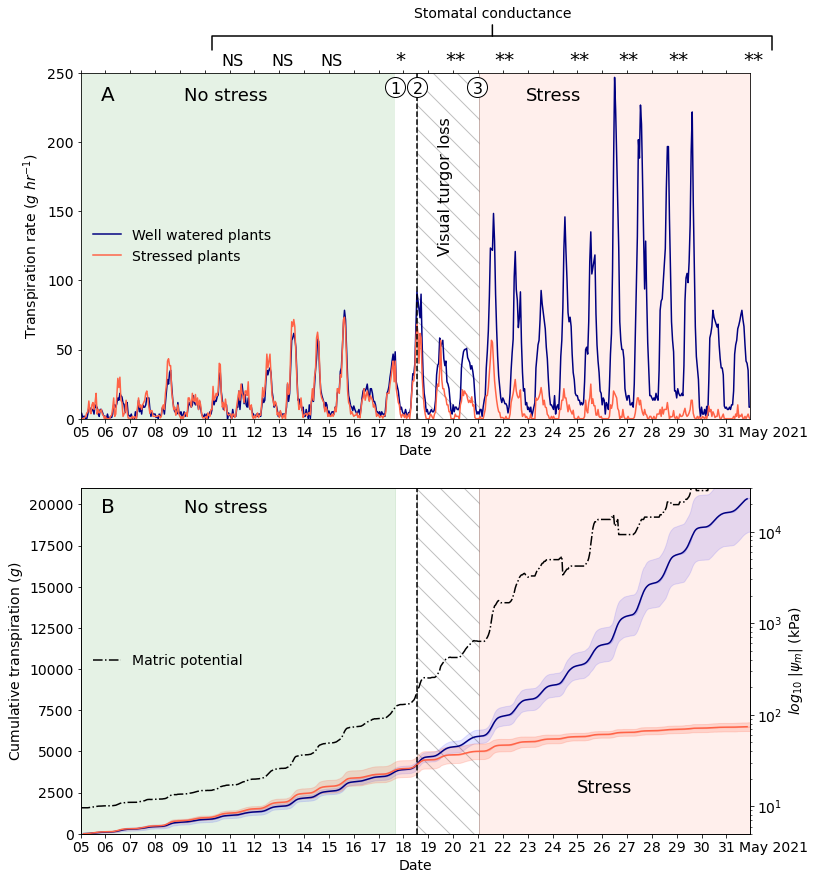

In [69]:
# Plot typical hourly transpiration rate for well watered plants versus specific stressed plants

fig = plt.figure(figsize=(12,14))

ax1 = fig.add_subplot(2,1,1)
ax1.plot(Tr['TIMESTAMP'], Tr_avg_well, color='navy', label='Well watered plants') #line_width=3 #divide by (70.7*24) to conver to mm/day
ax1.plot(Tr['TIMESTAMP'], Tr_avg_stress, color='tomato', label='Stressed plants') #line_width=3
ax1.set_ylabel('Transpiration rate ($g \ hr^{-1}$)', size=fontsize)
ax1.set_xlabel('Date', size=fontsize)

ax1.text(df['TIMESTAMP'].iloc[100], 230, 'No stress', size=18)
ax1.text(df['TIMESTAMP'].iloc[430], 230, 'Stress', size=18)
ax1.text(df['TIMESTAMP'].iloc[20], 230, 'A', size=20)
ax1.text(df['TIMESTAMP'].iloc[idx_stress+20], 120, 'Visual turgor loss', size=16, rotation='vertical') # Based on approximate observations from Sofia

ax1.legend(loc='center left', fontsize=fontsize, frameon=False)
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)
ax1.axvline(df['TIMESTAMP'].iloc[idx_stress], linestyle='--', color='k')
ax1.xaxis.set_major_formatter(date_form)
ax1.fill_betweenx([0,250], df['TIMESTAMP'].iloc[0],pd.to_datetime('2021-05-17 16:00:00'), color='green',alpha=0.1)
ax1.fill_betweenx([0,250], pd.to_datetime('2021-05-17 16:00:00'), df['TIMESTAMP'].iloc[idx_stress], color='white')
ax1.fill_betweenx([0,250], df['TIMESTAMP'].iloc[idx_stress], df['TIMESTAMP'].iloc[idx_stress+60], color='white', alpha=0.25, hatch='\\',edgecolor='black')
ax1.fill_betweenx([0,250], df['TIMESTAMP'].iloc[idx_stress+60], df['TIMESTAMP'].iloc[-1], color='tomato',alpha=0.1)
ax1.set_xlim(df['TIMESTAMP'].iloc[0], df['TIMESTAMP'].iloc[-1])
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.text(pd.to_datetime('2021-05-31 12:00:00'), -13, 'May 2021', size=fontsize)
ax1.set_ylim(0,250)


# Add numbers to denote stages in the manuscript
ax1.plot(pd.to_datetime('2021-05-17 16:00:00'), 240, marker='o', markerfacecolor='w', markeredgecolor='k', markersize=20)
ax1.text(pd.to_datetime('2021-05-17 11:00:00'), 235, '1', size=16)

ax1.plot(df['TIMESTAMP'].iloc[idx_stress], 240, marker='o', markerfacecolor='w', markeredgecolor='k', markersize=20)
ax1.text(df['TIMESTAMP'].iloc[idx_stress-4], 235, '2', size=16)

ax1.plot(df['TIMESTAMP'].iloc[idx_stress+58], 240, marker='o', markerfacecolor='w', markeredgecolor='k', markersize=20)
ax1.text(df['TIMESTAMP'].iloc[idx_stress+54], 235, '3', size=16)

# Add significance of the t-test for stomatal conductivity
ax1.xaxis.set_tick_params(top='on')
ax1.text(pd.to_datetime('2021-05-10 16:00:00'), 255, 'NS', size=16)
ax1.text(pd.to_datetime('2021-05-12 16:00:00'), 255, 'NS', size=16)
ax1.text(pd.to_datetime('2021-05-14 16:00:00'), 255, 'NS', size=16)
ax1.text(pd.to_datetime('2021-05-17 16:00:00'), 255, '*', size=20) # P0.0469
ax1.text(pd.to_datetime('2021-05-19 16:00:00'), 255, '**', size=20)
ax1.text(pd.to_datetime('2021-05-21 16:00:00'), 255, '**', size=20)
ax1.text(pd.to_datetime('2021-05-24 16:00:00'), 255, '**', size=20)
ax1.text(pd.to_datetime('2021-05-26 16:00:00'), 255, '**', size=20)
ax1.text(pd.to_datetime('2021-05-28 16:00:00'), 255, '**', size=20)
ax1.text(pd.to_datetime('2021-05-31 16:00:00'), 255, '**', size=20)

ax1.annotate('Stomatal conductance', xy=(0.615, 1.1), xytext=(0.615, 1.15), xycoords='axes fraction', 
            fontsize=14, ha='center', va='bottom',
            #bbox=dict(boxstyle=None, fc='white'),
            arrowprops=dict(arrowstyle='-[, widthB=20.0, lengthB=1', lw=1.5))


# Second subplot
ax2 = fig.add_subplot(2,1,2)

ax2.fill_betweenx([0,21000], df['TIMESTAMP'].iloc[0], pd.to_datetime('2021-05-17 16:00:00'), color='green',alpha=0.1)
ax2.fill_betweenx([0,21000], pd.to_datetime('2021-05-17 16:00:00'), df['TIMESTAMP'].iloc[idx_stress], color='white', alpha=0)
ax2.fill_betweenx([0,21000], df['TIMESTAMP'].iloc[idx_stress], df['TIMESTAMP'].iloc[idx_stress+60], color='white', alpha=0.25, hatch='\\',edgecolor='black')
ax2.fill_betweenx([0,21000], df['TIMESTAMP'].iloc[idx_stress+60], df['TIMESTAMP'].iloc[-1], color='tomato',alpha=0.1)

ax2.fill_between(Tr['TIMESTAMP'], Tr_avg_well.cumsum(), Tr_avg_well.cumsum() + Tr_ste_well*1.96, color='b', alpha=0.1)
ax2.fill_between(Tr['TIMESTAMP'], Tr_avg_well.cumsum(), Tr_avg_well.cumsum() - Tr_ste_well*1.96, color='b', alpha=0.1)
ax2.plot(Tr['TIMESTAMP'], Tr_avg_well.cumsum().rolling(window=7,center=True).mean(), color='navy', label='Well watered plants')

ax2.fill_between(Tr['TIMESTAMP'], Tr_avg_stress.cumsum(), Tr_avg_stress.cumsum() + Tr_ste_stress*1.96, color='tomato', alpha=0.2)
ax2.fill_between(Tr['TIMESTAMP'], Tr_avg_stress.cumsum(), Tr_avg_stress.cumsum() - Tr_ste_stress*1.96, color='tomato', alpha=0.2)
ax2.plot(Tr['TIMESTAMP'], Tr_avg_stress.cumsum().rolling(window=7,center=True).mean(), color='tomato', label='Stressed plants')

# Add labels
ax2.text(df['TIMESTAMP'].iloc[100], 19500, 'No stress', size=18)
ax2.text(df['TIMESTAMP'].iloc[480], 2500, 'Stress', size=18)
ax2.text(df['TIMESTAMP'][20], 19500, 'B', size=20)

ax2.axvline(df['TIMESTAMP'].iloc[idx_stress], linestyle='--',color='k')
ax2.set_ylabel('Cumulative transpiration ($g$)', size=fontsize)
ax2.tick_params(axis='x', labelsize=fontsize)
ax2.tick_params(axis='y', labelsize=fontsize)

ax2.xaxis.set_major_formatter(date_form)
ax2.set_xlim(df['TIMESTAMP'].iloc[0], df['TIMESTAMP'].iloc[-1])
ax2.set_ylim(0,21_000)
ax2.set_xlabel('Date', size=fontsize)

ax3 = ax2.twinx()
ax3.plot(matric['TIMESTAMP'], matric[stressed_scales].median(axis=1), '-.k', label='Matric potential')
ax3.tick_params(axis='y', labelsize=fontsize)
ax3.set_yscale(value='log')
ax3.set_ylim(5, 30_000)
ax3.set_ylabel('$log_{10} \ |\psi_m|$ (kPa)', size=fontsize)
ax3.legend(loc='center left', fontsize=fontsize, frameon=False)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.text(pd.to_datetime('2021-05-31 12:00:00'), 3.2, 'May 2021', size=fontsize)

plt.savefig('../figures/transpiration.jpg', dpi=300, transparent=False)
plt.show()


In [37]:
# Find the peak and decrease of trasnpiration rate on May 18 for well -watered plants.
# We used this to illustrate that even platns under well-watered conditions can show temporary stress.
idx_may_18 = (df['TIMESTAMP'] >= pd.to_datetime('2021-05-18 00:00:00', format="%Y-%m-%d %H:%M:%S")) & \
(df['TIMESTAMP'] < pd.to_datetime('2021-05-19 00:00:00', format="%Y-%m-%d %H:%M:%S"))

Tr_avg_well[idx_may_18]


312     3.333333
313     3.333333
314     6.666667
315     3.333333
316     1.666667
317     4.444444
318     4.444444
319     7.777778
320    20.833333
321    32.500000
322    31.666667
323    40.000000
324    66.666667
325    91.666667
326    85.416667
327    79.166667
328    72.916667
329    90.000000
330    55.000000
331    31.666667
332    18.333333
333    13.333333
334     5.000000
335     6.666667
dtype: float64

In [38]:
# Maximum average hourly transpiration rate
Tr_avg_well.max()


246.66666666666853

In [39]:
# Maximum hourly transpiration rate for any well-watered plant
Tr[well_watered_scales].max().max()*1000


309.99999999999517

In [114]:
df['TIMESTAMP'].iloc[idx_stress+58] - df['TIMESTAMP'].iloc[idx_stress]

Timedelta('2 days 10:00:00')

In [115]:
df['TIMESTAMP'].iloc[idx_stress] - pd.to_datetime('2021-05-17 16:00:00')

Timedelta('0 days 21:00:00')

In [117]:
df['TIMESTAMP'].iloc[idx_stress+58] - pd.to_datetime('2021-05-17 16:00:00')

Timedelta('3 days 07:00:00')

In [40]:
# DAY-time transpiration of well-watered plants
T_total_daytime = 0
day = False
for k,row in Tr_well.iterrows():
    if (df.loc[k,'PAR_Den_Avg'] > 1) and (day == False):
        k_start = k
        day = True
    elif (df.loc[k,'PAR_Den_Avg'] < 1) and (day == True):
        k_end = k
        day = False
        T_day = Tr_avg_well.iloc[k_start:k_end].sum()
        VPD = df.loc[k_start:k_end,'VPD'].median()
        print('T:',round(T_day,2), ' VPD:',round(VPD,1), ' start:', df.loc[k_start,'TIMESTAMP'],' end:',df.loc[k_end,'TIMESTAMP'])
        T_total_daytime += T_day

print(f'Total daytime T: {round(T_total_daytime)} (g)')


T: 90.0  VPD: 1.9  start: 2021-05-05 06:00:00  end: 2021-05-05 22:00:00
T: 168.33  VPD: 2.0  start: 2021-05-06 06:00:00  end: 2021-05-06 22:00:00
T: 131.67  VPD: 1.9  start: 2021-05-07 06:00:00  end: 2021-05-07 22:00:00
T: 235.83  VPD: 2.5  start: 2021-05-08 06:00:00  end: 2021-05-08 22:00:00
T: 146.67  VPD: 1.7  start: 2021-05-09 06:00:00  end: 2021-05-09 22:00:00
T: 229.17  VPD: 1.7  start: 2021-05-10 06:00:00  end: 2021-05-10 22:00:00
T: 190.0  VPD: 1.5  start: 2021-05-11 06:00:00  end: 2021-05-11 22:00:00
T: 311.67  VPD: 1.7  start: 2021-05-12 06:00:00  end: 2021-05-12 22:00:00
T: 472.5  VPD: 1.9  start: 2021-05-13 06:00:00  end: 2021-05-13 22:00:00
T: 371.67  VPD: 1.7  start: 2021-05-14 06:00:00  end: 2021-05-14 22:00:00
T: 535.83  VPD: 1.9  start: 2021-05-15 06:00:00  end: 2021-05-15 22:00:00
T: 260.0  VPD: 1.6  start: 2021-05-16 07:00:00  end: 2021-05-16 22:00:00
T: 403.33  VPD: 1.7  start: 2021-05-17 06:00:00  end: 2021-05-17 22:00:00
T: 741.39  VPD: 2.1  start: 2021-05-18 06:0

In [41]:
# NIGHT-time transpiration of well-watered plants
T_total_nighttime = 0
night = False
for k,row in Tr_well.iterrows():
    if (df.loc[k,'PAR_Den_Avg'] < 1) and (night == False):
        k_start = k
        night = True
    elif (df.loc[k,'PAR_Den_Avg'] > 1) and (night == True):
        k_end = k
        night = False
        T_night = Tr_avg_well.iloc[k_start:k_end].sum()
        VPD = df.loc[k_start:k_end,'VPD'].median()
        print('T:',round(T_night,2), ' VPD:',round(VPD,1), ' start:', df.loc[k_start,'TIMESTAMP'],' end:',df.loc[k_end,'TIMESTAMP'])
        T_total_nighttime += T_night

print(f'Total nighttime T: {round(T_total_nighttime)} (g)')

T: 12.33  VPD: 1.3  start: 2021-05-05 00:00:00  end: 2021-05-05 06:00:00
T: 10.83  VPD: 1.4  start: 2021-05-05 22:00:00  end: 2021-05-06 06:00:00
T: 15.0  VPD: 1.4  start: 2021-05-06 22:00:00  end: 2021-05-07 06:00:00
T: 17.5  VPD: 1.4  start: 2021-05-07 22:00:00  end: 2021-05-08 06:00:00
T: 35.0  VPD: 1.3  start: 2021-05-08 22:00:00  end: 2021-05-09 06:00:00
T: 16.67  VPD: 1.3  start: 2021-05-09 22:00:00  end: 2021-05-10 06:00:00
T: 18.33  VPD: 1.4  start: 2021-05-10 22:00:00  end: 2021-05-11 06:00:00
T: 22.5  VPD: 1.3  start: 2021-05-11 22:00:00  end: 2021-05-12 06:00:00
T: 28.33  VPD: 1.3  start: 2021-05-12 22:00:00  end: 2021-05-13 06:00:00
T: 37.5  VPD: 1.4  start: 2021-05-13 22:00:00  end: 2021-05-14 06:00:00
T: 36.67  VPD: 1.4  start: 2021-05-14 22:00:00  end: 2021-05-15 06:00:00
T: 51.67  VPD: 1.4  start: 2021-05-15 22:00:00  end: 2021-05-16 07:00:00
T: 31.67  VPD: 1.3  start: 2021-05-16 22:00:00  end: 2021-05-17 06:00:00
T: 36.11  VPD: 1.4  start: 2021-05-17 22:00:00  end: 202

In [42]:
T_total_nighttime/(T_total_nighttime +T_total_daytime)*100

7.0118358109921575

In [43]:
print('Mean total transpiration well watered plants:',(Tr[well_watered_scales].sum()*1000).mean())
print('Std total transpiration well watered plants:',(Tr[well_watered_scales].sum()*1000).std())

print('Mean total transpiration well watered plants:',(Tr[stressed_scales].sum()*1000).mean())
print('Std total transpiration well watered plants:',(Tr[stressed_scales].sum()*1000).std())


Mean total transpiration well watered plants: 20399.58333333334
Std total transpiration well watered plants: 2575.691371586789
Mean total transpiration well watered plants: 6505.41666666666
Std total transpiration well watered plants: 332.1385880421994


In [44]:
hours = Tr['TIMESTAMP'].dt.hour

In [97]:
Tr_hour_well = []
for h in range(24):
    idx = hours == h
    Tr_hour_well.append( np.sum(Tr_avg_well[idx])/np.sum(Tr_avg_well)*100)
    

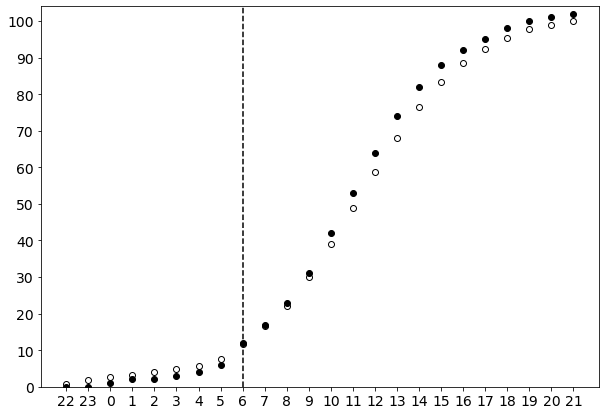

In [112]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(1,1,1)

ax.scatter(np.roll(np.arange(24),2), np.roll(np.cumsum(Tr_hour_well),2), facecolor='w',edgecolor='k')
#ax.fill_betweenx([0,100], 0, 8, color='grey',alpha=0.1)
ax.axvline(6+2, linestyle='--',color='k')

ax.scatter(np.roll(np.arange(24),2), np.roll(np.cumsum(Tr_hour_stress),2), facecolor='k',edgecolor='k')

ax.set_xticks(np.arange(24))
ax.set_xticklabels(np.roll(np.arange(24),2), size=14)
ax.set_yticks(np.arange(0,110,10))
ax.set_yticklabels(np.arange(0,110,10), size=14)
ax.set_ylim([0,104])
ax.set

plt.show()


In [98]:
np.cumsum(Tr_hour_well)

array([  0.8963201 ,   1.73137896,   2.60074412,   3.32907227,
         4.03834137,   4.89191474,   5.64883148,   7.56698917,
        11.71369488,  16.54652656,  22.21795662,  29.93483165,
        39.1634981 ,  48.88715542,  58.68650442,  68.12659024,
        76.5072649 ,  83.33027027,  88.56756231,  92.39679862,
        95.39043154,  97.81229282,  99.01029053, 100.        ])

In [74]:
np.roll(np.arange(24),2)

array([22, 23,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
       15, 16, 17, 18, 19, 20, 21])

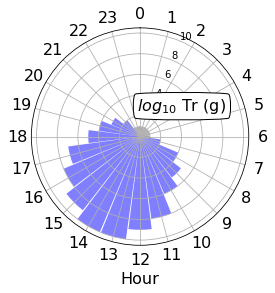

In [56]:
ax = plt.subplot(111, polar=True)

N = 24
theta = np.arange(0.0, 2 * np.pi, 2 * np.pi / N)
#radii = np.log10(Tr_hour_well)
radii = Tr_hour_well

width = 0.25
bars = plt.bar(theta, radii, width=width, bottom=0.0)

counter = 0
for r,bar in zip(radii, bars):
    if counter in [22,23,0,1,2,3,4,5,6]:
        bar.set_facecolor('darkgrey')
        bar.set_alpha(1)
    else:
        bar.set_facecolor('blue')
        bar.set_alpha(0.5)

    counter += 1

ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels(range(24), size=16)      

# Make the labels go clockwise
ax.set_theta_direction(-1)       

# Place 0 at the top
ax.set_theta_offset(np.pi/2.0)  

ax.set_xlabel('Hour', size=16)

ax.annotate('$log_{10}$ Tr (g)',
                  xy=(theta[2], 2.5), xycoords='data',
                  xytext=(2.3*np.pi, 5), textcoords='data',
                  size=16, va="center", ha="center",
                  bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  connectionstyle="arc3,rad=-0.2",
                                  fc="w"),
                  )

#ax.set_xticklabels([])
#ax.set_yticklabels([])
plt.savefig('../figures/daytime_nighttime_well.jpg', dpi=300, transparent=False, bbox_inches='tight')

plt.show()


In [63]:
Tr_hour_stress = []
for h in range(24):
    idx = hours == h
    #Tr_hour_stress.append(np.round(np.sum(Tr_avg_stress[idx])))
    Tr_hour_stress.append( np.round(np.sum(Tr_avg_stress[idx])/np.sum(Tr_avg_stress)*100) )


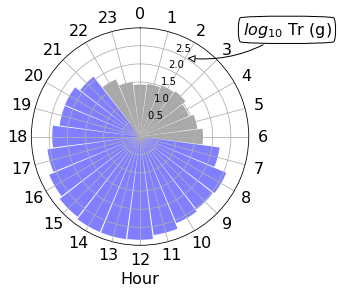

In [52]:
ax = plt.subplot(111, polar=True)

N = 24
theta = np.arange(0.0, 2 * np.pi, 2 * np.pi / N)
radii = np.log10(Tr_hour_stress)

width = 0.25
bars = plt.bar(theta, radii, width=width, bottom=0.0)

counter = 0
for r,bar in zip(radii, bars):
    if counter in [22,23,0,1,2,3,4,5,6]:
        bar.set_facecolor('darkgrey')
        bar.set_alpha(1)
    else:
        bar.set_facecolor('blue')
        bar.set_alpha(0.5)

    counter += 1

ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels(range(24), size=16)      

# Make the labels go clockwise
ax.set_theta_direction(-1)       

# Place 0 at the top
ax.set_theta_offset(np.pi/2.0)  

ax.set_xlabel('Hour', size=16)

ax.annotate('$log_{10}$ Tr (g)',
                  xy=(theta[2], 2.5), xycoords='data',
                  xytext=(2.3*np.pi, 5), textcoords='data',
                  size=16, va="center", ha="center",
                  bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  connectionstyle="arc3,rad=-0.2",
                                  fc="w"),
                  )

#ax.set_xticklabels([])
#ax.set_yticklabels([])
plt.savefig('../figures/daytime_nighttime_stress.jpg', dpi=300, transparent=False, bbox_inches='tight')

plt.show()

# Code below was not used and it may not work.

## Calculation of Normalized Tranpiration Ratio 

The computation involves two normalizations:

**Normalization 1**: Transpiration of stressed plants is divided by the mean value of the well watered plants

**Normalization 2**: Each value of the previous normalization for the stressed plants is divided by the mean of the first 3 days, time at which all the plants were well-watered.

Reference for this method: Ray, J.D. and Sinclair, T.R., 1997. Stomatal closure of maize hybrids in response to drying soil. Crop Science, 37(3), pp.803-807.

In [108]:
# Normalization 1

NTR1 = pd.DataFrame()
NTR1['Q'] = Tr_daily['Q'] / Tr_daily_avg
NTR1['W'] = Tr_daily['W'] / Tr_daily_avg
NTR1['S'] = Tr_daily['S'] / Tr_daily_avg
NTR1['Y'] = Tr_daily['Y'] / Tr_daily_avg
NTR1['O'] = Tr_daily['O'] / Tr_daily_avg
NTR1['U'] = Tr_daily['U'] / Tr_daily_avg


NameError: name 'Tr_daily' is not defined

In [ ]:
# Normalization 2
NTR2 = pd.DataFrame()
N = 3
NTR2['Q'] = NTR1['Q'] / NTR1['Q'][0:N].mean()
NTR2['W'] = NTR1['W'] / NTR1['W'][0:N].mean()
NTR2['S'] = NTR1['S'] / NTR1['S'][0:N].mean()
NTR2['Y'] = NTR1['Y'] / NTR1['Y'][0:N].mean()
NTR2['O'] = NTR1['O'] / NTR1['O'][0:N].mean()
NTR2['U'] = NTR1['U'] / NTR1['U'][0:N].mean()

NTR2.reset_index(inplace=True, drop=True)
#NTR2_all = pd.concat([NTR2['Q'],NTR2['W'],NTR2['Y'],NTR2['O'],NTR2['U'],NTR2['S']]).reset_index(drop=True)#


## Fraction of Transpirable Water

## Alternative using values at drainge point

In [109]:
# Linear Plateau code 

# It can be run with FTSW_all and NTR2_all or individual plants.
# It must be a Pandas series to run.


from scipy.stats import linregress

# Search values of FTSW for the break point. About 50 values should be fine to get close enough
x_range = np.linspace(0.1,0.45,50)

# Rename variables to x and y to keep the code shorter and more generic
x = VWC_daily.iloc[:,2:].values.flatten()
y = NTR2_all = NTR2.values.flatten()
idx = np.argsort(x)
x = x[idx]
y = y[idx] # sort values in y acccording to the order in x to avoid mixing the data

mae_best = np.inf # infinitely large mean absolute error
threshold_stress = 0 # initialize the threshold

for k in x_range:
    idx = (x <= k)
    slope, intercept, r, pval, se = linregress(x[idx], y[idx]) # Linear model
    constant = intercept + slope*k # Constant model from the last point of the linear model
    
    error = y[idx] - (intercept + slope*x[idx]) 
    error =  np.append(error, (y[~idx] - constant))
    mae = np.mean(np.abs(error)) # Mean Absolute Error (MAE) of current iteration
    
    # If new MAE is lower than the best mae, then save the regression parameters
    if mae < mae_best:
        threshold_stress = k
        slope_best = slope
        intercept_best = intercept
        constant_best = constant
        p_value_best = pval
        mae_best = mae

# Print regression coefficients
print('VWC stress:', round(threshold_stress,2))
print('MAE:', round(mae_best,2), 
      'p_value:',p_value_best,
      'intercept:',intercept_best,
      'slope:', slope_best)

x_intercept = -intercept/slope # Point at which the linear plateau crosses the x-axis.


NameError: name 'NTR2' is not defined

In [ ]:
# Linear Plateau figure

plt.figure(figsize=(8,12))

plt.subplot(2,1,1)
plt.scatter(x, y, color='navy', marker='s', facecolor='None')
plt.plot([0,threshold_stress], [intercept_best,intercept_best+slope_best*threshold_stress], '-k')
plt.plot([threshold_stress,0.35], [constant_best,constant_best], '-k') #line_width=3 Constant model
plt.axvline(threshold_stress,linestyle='--',color='k')
plt.text(0, 1.1, 'A', size=20) 
plt.ylim(0, 1.25)
plt.xlabel('$ \\theta \ (cm^3 cm^{-3})$', size=fontsize)
plt.ylabel('Normalized transpiration ratio', size=fontsize)
plt.xticks(size=fontsize)
plt.yticks(size=fontsize)

plt.subplot(2,1,2)
plt.scatter(PSI['Q'], NTR2['Q'], color='navy', marker='s', facecolor='None')
plt.scatter(PSI['W'], NTR2['W'], color='navy', marker='s', facecolor='None') 
plt.scatter(PSI['Y'], NTR2['Y'], color='navy', marker='s', facecolor='None') 
plt.scatter(PSI['S'], NTR2['S'], color='navy', marker='s', facecolor='None') 
plt.scatter(PSI['S'], NTR2['S'], color='navy', marker='s', facecolor='None') 
plt.scatter(PSI['O'], NTR2['O'], color='navy', marker='s', facecolor='None')
plt.scatter(PSI['U'], NTR2['U'], color='navy', marker='s', facecolor='None')
plt.xscale(value='log')
plt.ylabel('Normalized transpiration ratio', size=fontsize)
plt.xlabel('$log_{10}|\psi_m|$ (kPa)', size=fontsize)
plt.text(10**5.6,1.1, 'B', size=20) 
plt.xlim(5, 10**6)
plt.ylim(0, 1.25)
plt.xticks(size=fontsize)
plt.yticks(size=fontsize)

plt.subplots_adjust(hspace=0.3)
plt.savefig('stress_curve.png', dpi=300)
plt.show()

